# HotpotQA Span FFT vs Full Cross-Encoder

这个 notebook 直接复用 HotpotQA 的 span 扫描缓存，只针对单个 `span` 做比较：

- 不运行 LiteSemRAG 的扫描、索引建立或聚类。
- 从 scan cache 取出这个 span 的全部文本出现位置。
- 重新建立这些文本的 embedding。
- 用 `farthest_first_traversal` 选样本，只对样本跑 cross-encoder，然后按 LiteSemRAG 当前算法把剩余样本分类。
- 再对全部样本逐个跑 cross-encoder。
- 额外运行一组 `FFT sample and algorithm propagation` 的 LLM 版本：原设置里需要 cross-encoder 语义判断的位置改用 LLM 判断，可在单条样本 prompt 和多条样本 batch prompt 之间切换。
- 直接展示文本结果和可视化，不保存结果到本地。
- 对 full cross-encoder 与 LLM semantic labeling 的不一致条目，先汇总各类别误判转移统计（含多类别时的全部 truth→prediction 计数与矩阵），再逐条展示各候选语义的 cross-encoder 分数。

如果要换词，只需要修改 `TARGET_SPAN` 这一组参数，然后从下往下重新运行。


In [1]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")

Working directory: /home/xiaoyue/LiteSemRAG


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import pickle
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from IPython.display import display
from sentence_transformers import CrossEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

from text_processing import get_token_indices_for_phrase, normalize_text
from utils import (
    build_wikidata_candidate_bank as shared_build_wikidata_candidate_bank,
    extract_cross_encoder_scores,
    farthest_first_traversal,
    load_wikidata_definition_candidates as shared_load_wikidata_definition_candidates,
)
from wikidata_utils import fetch_detailed_descriptions_for_entities
from wikidata_definition_filter import WikidataDefinitionFilter
from llm_semantic_labeler import (
    DEFAULT_CACHE_PATH as DEFAULT_LLM_CACHE_PATH,
    DEFAULT_CONTEXT_WORD_WINDOW as DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    DEFAULT_MAX_TOKENS as DEFAULT_LLM_MAX_TOKENS,
    choose_wikidata_candidate_with_llm,
)
from local_llm import LocalLLMClient, LocalLLMConfig


In [3]:
HOTPOT_SCAN_STORE_PATH = Path("hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl")
DEFAULT_CROSS_ENCODER_MODEL = "cross-encoder/nli-deberta-v3-large"
DEFAULT_TEXT_ENCODER_NAME_OR_PATH = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"
DEFAULT_BATCH_SIZE = 16
DEFAULT_MAX_LENGTH = 512
DEFAULT_CONTEXT_MODE = "sentence_neighbors"  # "sentence", "sentence_neighbors", "full_text"
DEFAULT_REDUCTION_METHOD = "tsne"  # "pca" or "tsne"
DEFAULT_RANDOM_STATE = 42
DEFAULT_CONSENSUS_RATIO_THRESHOLD = 0.9
DEFAULT_D1_D2_RATIO_THRESHOLD = 0.8
DEFAULT_MAX_SAMPLES = 10
DEFAULT_FFT_KNN_CHECK_K = 5
DEFAULT_FFT_DANGER_NEIGHBOR_M = 10
DEFAULT_QUERY_KIND = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
pd.set_option("display.max_colwidth", None)
print(f"Device: {DEVICE}")


Device: cuda


In [4]:
def load_hotpot_scan_store(scan_store_path: Path = HOTPOT_SCAN_STORE_PATH):
    if not scan_store_path.exists():
        raise FileNotFoundError(
            f"HotpotQA scan store not found at {scan_store_path}. Please prepare the scan cache first."
        )

    with scan_store_path.open("rb") as handle:
        store = pickle.load(handle)

    print(f"Loaded scan-only store from {scan_store_path}")
    print(store["stats"])
    return store


embedding_store = load_hotpot_scan_store()

Loaded scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl
{'num_documents': 66581, 'num_unique_terms': 634624, 'num_phrase_occurrences': 1007780, 'num_token_occurrences': 584999, 'num_total_occurrences': 1592779}


In [5]:
def lookup_records(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def _find_left_boundary(text: str, index: int) -> int:
    return max(
        text.rfind(".", 0, index),
        text.rfind("!", 0, index),
        text.rfind("?", 0, index),
    )


def _find_right_boundary(text: str, index: int) -> int:
    right_candidates = [
        text.find(".", index),
        text.find("!", index),
        text.find("?", index),
    ]
    right_candidates = [idx for idx in right_candidates if idx != -1]
    return len(text) if not right_candidates else min(right_candidates) + 1


def _build_context_from_bounds(cleaned_text, span, context_start, context_end):
    start_char, end_char = span
    context_raw = cleaned_text[context_start:context_end]

    if not context_raw.strip():
        context_start = max(0, start_char - 120)
        context_end = min(len(cleaned_text), end_char + 120)
        context_raw = cleaned_text[context_start:context_end]

    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - context_start - left_trim
    local_end = end_char - context_start - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)
    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_neighbor_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)

    if context_start > 0:
        previous_boundary = _find_left_boundary(cleaned_text, max(0, context_start - 1))
        context_start = 0 if previous_boundary == -1 else previous_boundary + 1

    if context_end < len(cleaned_text):
        context_end = _find_right_boundary(cleaned_text, context_end)

    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_full_context(cleaned_text, span):
    start_char, end_char = span
    context_raw = cleaned_text
    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - left_trim
    local_end = end_char - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_prompt_context(cleaned_text, span, prompt_context_mode="sentence"):
    if prompt_context_mode == "sentence":
        return extract_sentence_context(cleaned_text, span)
    if prompt_context_mode == "full_text":
        return extract_full_context(cleaned_text, span)
    if prompt_context_mode == "sentence_neighbors":
        return extract_neighbor_sentence_context(cleaned_text, span)
    raise ValueError(
        f"Unsupported prompt_context_mode={prompt_context_mode!r}. Use 'sentence', 'sentence_neighbors', or 'full_text'."
    )


def build_hotpot_prompt(
    record,
    query_text,
    mark_target=False,
    left_marker="[TGT]",
    right_marker="[/TGT]",
    prompt_context_mode="sentence",
):
    context_info = extract_prompt_context(
        record["cleaned_text"],
        record["span"],
        prompt_context_mode=prompt_context_mode,
    )
    context_text = context_info["context_text"]
    local_start, local_end = context_info["local_span"]
    prompt_context = context_text

    if mark_target:
        prompt_context = (
            f"{context_text[:local_start]}{left_marker} {context_text[local_start:local_end]} {right_marker}{context_text[local_end:]}"
        )

    prompt_text = (
        f"Context: {prompt_context}\n"
        f"Target word: {query_text.strip()}\n\n"
        f'Question: What does "{query_text.strip()}" mean in this context?'
    )

    return {
        "context_text": context_text,
        "matched_text": context_text[local_start:local_end],
        "local_span": (local_start, local_end),
        "prompt_text": prompt_text,
    }


In [6]:
def load_wikidata_definition_candidates(
    query_text: str,
    use_detailed_description: bool = True,
    exact_match_text: bool = False,
    filter_name: bool = True,
    require_detailed_description: bool = False,
    candidate_limit: int = 5,
    use_llm_filter: bool = False,
    llm_filter_use_api: bool = False,
    llm_filter_api_model: str | None = None,
    llm_filter_cache_path: Path | str = "cache/wikidata_definition_filter_cache.sqlite3",
    llm_filter_use_cache: bool = True,
    llm_filter_write_cache: bool = True,
):
    llm_filter = None
    if use_llm_filter:
        llm_filter = WikidataDefinitionFilter(
            use_api=llm_filter_use_api,
            api_model=llm_filter_api_model,
            cache_path=llm_filter_cache_path,
        )

    return shared_load_wikidata_definition_candidates(
        query_text,
        use_detailed_description=use_detailed_description,
        exact_match_text=exact_match_text,
        limit=int(candidate_limit),
        filter_name=filter_name,
        require_detailed_description=require_detailed_description,
        target_candidate_count=int(candidate_limit) if use_llm_filter else None,
        use_llm_filter=use_llm_filter,
        llm_filter=llm_filter,
        llm_filter_use_api=llm_filter_use_api,
        llm_filter_use_cache=llm_filter_use_cache,
        llm_filter_write_cache=llm_filter_write_cache,
    )


def build_wikidata_candidate_bank(candidates_df: pd.DataFrame, definition_column: str):
    return shared_build_wikidata_candidate_bank(candidates_df, definition_column)


In [7]:
text_tokenizer = None
text_encoder_model = None
cross_encoder_model = None


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise RuntimeError(
            "The text encoder tokenizer must be a fast tokenizer because offset_mapping is required."
        )

    loaded_model = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_tokenizer, loaded_model


def ensure_text_encoder_loaded(name_or_path: str, device: str):
    global text_tokenizer, text_encoder_model
    if text_tokenizer is None or text_encoder_model is None:
        text_tokenizer, text_encoder_model = load_text_encoder(name_or_path, device)
        print(f"Loaded text encoder on {device}: {name_or_path}")
    return text_tokenizer, text_encoder_model


def ensure_cross_encoder_loaded(model_name: str):
    global cross_encoder_model
    if cross_encoder_model is None:
        cross_encoder_model = CrossEncoder(model_name)
        print(f"Loaded cross-encoder: {model_name}")
    return cross_encoder_model


def encode_span_text_batch(text_list, tokenizer, model, device, max_length=512):
    encoded_inputs = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offsets = encoded_inputs["offset_mapping"]
    model_inputs = {key: value.to(device) for key, value in encoded_inputs.items() if key != "offset_mapping"}

    with torch.no_grad():
        outputs = model(**model_inputs, output_hidden_states=True)
        token_embeddings = outputs.hidden_states[-2].detach().cpu()

    return token_embeddings, offsets


In [8]:
def collect_query_span_embeddings(
    store,
    query_text,
    kind=None,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=False,
    max_records=None,
    text_encoder_name_or_path=None,
    device=DEVICE,
):
    normalized_query = normalize_text(query_text.strip())
    query_records = lookup_records(
        store,
        query_text,
        kind=kind,
        include_text=True,
        include_cleaned_text=True,
    )

    if not query_records:
        raise ValueError(f"No records found for span={query_text!r}.")

    if max_records is not None:
        query_records = query_records[: int(max_records)]

    embedding_cache = store.setdefault("embedding_cache", {})
    encoder_name = text_encoder_name_or_path or DEFAULT_TEXT_ENCODER_NAME_OR_PATH
    tokenizer, model = ensure_text_encoder_loaded(encoder_name, device)

    total_records = len(query_records)
    progress_handle = display(
        f"Embedded 0/{total_records} texts for query {normalized_query!r}",
        display_id=True,
    )

    embedded_records = []
    cache_hits = 0
    cache_misses = 0

    for batch_start in range(0, total_records, batch_size):
        batch_end = min(batch_start + batch_size, total_records)
        batch_records = query_records[batch_start:batch_end]

        context_texts = []
        local_spans = []
        matched_texts = []
        batch_embeddings = [None] * len(batch_records)
        uncached_texts = []
        uncached_indices = []
        cache_keys = []

        for local_idx, record in enumerate(batch_records):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            cache_key = (
                int(record["document_idx"]),
                tuple(record["span"]),
                prompt_context_mode,
                prompt_info["context_text"],
                tuple(prompt_info["local_span"]),
                int(max_length),
                encoder_name,
                "litsemrag_hidden_states_minus_2_mean_pool_context_only",
            )

            matched_texts.append(prompt_info["matched_text"])
            context_texts.append(prompt_info["context_text"])
            local_spans.append(prompt_info["local_span"])
            cache_keys.append(cache_key)

            cached_embedding = embedding_cache.get(cache_key)
            if cached_embedding is None:
                uncached_texts.append(prompt_info["context_text"])
                uncached_indices.append(local_idx)
                cache_misses += 1
            else:
                batch_embeddings[local_idx] = cached_embedding
                cache_hits += 1

        if uncached_texts:
            token_embeddings_batch, offsets_batch = encode_span_text_batch(
                uncached_texts,
                tokenizer,
                model,
                device,
                max_length=max_length,
            )
            for local_idx, token_embeddings, offsets in zip(
                uncached_indices,
                token_embeddings_batch,
                offsets_batch,
            ):
                start_char, end_char = local_spans[local_idx]
                token_indices = get_token_indices_for_phrase(start_char, end_char, offsets.tolist())
                if not token_indices:
                    raise ValueError(
                        f"No tokenizer offsets were found for local_span={(start_char, end_char)} in title={batch_records[local_idx]['title']!r}."
                    )
                embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
                cache_key = cache_keys[local_idx]
                embedding_cache[cache_key] = embedding
                batch_embeddings[local_idx] = embedding

        for record, matched_text, context_text, local_span, embedding in zip(
            batch_records,
            matched_texts,
            context_texts,
            local_spans,
            batch_embeddings,
        ):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            item = dict(record)
            item["matched_text"] = matched_text
            item["context_text"] = context_text
            item["local_span"] = local_span
            item["prompt_text"] = prompt_info["prompt_text"]
            item["embedding"] = np.asarray(embedding, dtype=np.float32)
            item["record_index"] = len(embedded_records)
            embedded_records.append(item)

        progress_handle.update(
            f"Embedded {batch_end}/{total_records} texts for query {normalized_query!r}"
        )

    return {
        "query_text": query_text,
        "normalized_query": normalized_query,
        "kind": kind,
        "record_count": len(embedded_records),
        "batch_size": batch_size,
        "max_length": max_length,
        "prompt_context_mode": prompt_context_mode,
        "mark_target": mark_target,
        "max_records": max_records,
        "device": device,
        "text_encoder_name_or_path": encoder_name,
        "embedding_method": "LiteSemRAG span mean-pool from hidden_states[-2]",
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
        "cache_size": len(embedding_cache),
        "records": embedded_records,
    }


In [9]:
def score_record_candidates(record, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    pairs = [(record["prompt_text"], candidate["hypothesis"]) for candidate in candidate_bank]
    raw_scores = model.predict(
        pairs,
        batch_size=min(batch_size, len(pairs)),
        show_progress_bar=False,
    )
    scores = extract_cross_encoder_scores(raw_scores, model)
    ranked_candidates = sorted(
        [
            {
                **candidate,
                "score": float(score),
            }
            for candidate, score in zip(candidate_bank, scores)
        ],
        key=lambda item: item["score"],
        reverse=True,
    )
    return ranked_candidates


def classify_records_full_cross_encoder(records, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    predictions = []
    for record in records:
        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        predictions.append(
            {
                "record_index": record["record_index"],
                "assigned_description": top_candidate["description"],
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "score": float(top_candidate["score"]),
                "ranked_candidates": ranked_candidates,
                "provenance": "full_cross_encoder",
            }
        )
    return predictions


def _cosine_distance_matrix(embeddings: np.ndarray) -> np.ndarray:
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized.T
    dists = 1.0 - sims
    return np.clip(dists, 0.0, None)


def _compute_medoid_index_numpy(embeddings: np.ndarray) -> int:
    if len(embeddings) == 1:
        return 0
    dists = _cosine_distance_matrix(embeddings)
    return int(np.argmin(dists.sum(axis=1)))


def _nearest_medoid_distances(record_embedding: np.ndarray, medoid_embeddings: np.ndarray):
    record_vec = record_embedding / max(np.linalg.norm(record_embedding), 1e-12)
    medoid_vecs = medoid_embeddings / np.clip(np.linalg.norm(medoid_embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = medoid_vecs @ record_vec
    dists = np.clip(1.0 - sims, 0.0, None)
    order = np.argsort(dists)
    return dists, order


def _nearest_embedding_indices(embeddings: np.ndarray, target_idx: int, count: int):
    if count <= 0 or len(embeddings) <= 1:
        return []
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized[target_idx]
    dists = np.clip(1.0 - sims, 0.0, None)
    dists[target_idx] = np.inf
    neighbor_count = min(int(count), len(embeddings) - 1)
    return [int(idx) for idx in np.argsort(dists)[:neighbor_count]]


def _candidate_assignment(
    record,
    candidate,
    provenance,
    *,
    score=None,
    d1=None,
    d2=None,
    ratio=None,
    was_sampled=False,
    llm_reason=None,
    llm_cache_hit=None,
):
    return {
        "record_index": record["record_index"],
        "assigned_description": candidate.get("description"),
        "predicted_entity_id": candidate.get("entity_id"),
        "predicted_label": candidate.get("label"),
        "predicted_definition": candidate.get("definition"),
        "score": score,
        "provenance": provenance,
        "d1": d1,
        "d2": d2,
        "ratio": ratio,
        "was_sampled": was_sampled,
        "llm_reason": llm_reason,
        "llm_cache_hit": llm_cache_hit,
    }


def _classify_records_fft_then_assign_with_safety(
    records,
    candidate_bank,
    *,
    judge_records_fn,
    sample_judge_records_fn=None,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    provenance_prefix="",
    include_llm_metadata=False,
    result_metadata=None,
):
    if not records:
        raise ValueError("records must be non-empty")

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    if len(records) > max_samples:
        sampled_indices = list(farthest_first_traversal(embeddings, max_samples, start="random"))
    else:
        sampled_indices = list(range(len(records)))

    records_by_index = {record["record_index"]: record for record in records}
    position_by_record_index = {record["record_index"]: pos for pos, record in enumerate(records)}
    sampled_records = [records[idx] for idx in sampled_indices]
    sampled_index_set = {record["record_index"] for record in sampled_records}
    prediction_cache = {}
    sample_judge_records_fn = sample_judge_records_fn or judge_records_fn

    def judge_records_and_update(batch_records, *, judge_fn=None):
        active_judge_fn = judge_fn or judge_records_fn
        uncached_records = []
        seen_record_indices = set()
        for record in batch_records:
            record_index = record["record_index"]
            if record_index in prediction_cache or record_index in seen_record_indices:
                continue
            uncached_records.append(record)
            seen_record_indices.add(record_index)

        if uncached_records:
            judged = active_judge_fn(uncached_records)
            for record in uncached_records:
                record_index = record["record_index"]
                candidate = judged.get(record_index)
                if candidate is None:
                    raise ValueError(f"No semantic judgment produced for record_index={record_index}")
                prediction_cache[record_index] = candidate

        return {
            record["record_index"]: prediction_cache[record["record_index"]]
            for record in batch_records
        }

    def get_or_judge_record(record):
        return judge_records_and_update([record])[record["record_index"]]

    sample_judgments = judge_records_and_update(
        sampled_records,
        judge_fn=sample_judge_records_fn,
    )

    sample_prediction_records = []
    description_vote_map = {}
    for sample_order, record in enumerate(sampled_records, start=1):
        top_candidate = prediction_cache[record["record_index"]]
        description = top_candidate["description"]
        state = description_vote_map.setdefault(
            description,
            {
                "candidate": top_candidate,
                "description": description,
                "count": 0,
                "score_sum": 0.0,
                "score_count": 0,
            },
        )
        score = top_candidate.get("score")
        state["count"] += 1
        state["score_sum"] += 0.0 if score is None else float(score)
        state["score_count"] += 1
        sample_prediction_records.append(
            {
                "record_index": record["record_index"],
                "sample_order": sample_order,
                "predicted_description": description,
                "predicted_entity_id": top_candidate.get("entity_id"),
                "predicted_label": top_candidate.get("label"),
                "predicted_definition": top_candidate.get("definition"),
                "prediction_score": None if score is None else float(score),
                "llm_reason": top_candidate.get("llm_reason"),
                "llm_cache_hit": top_candidate.get("llm_cache_hit"),
            }
        )

    aggregated_candidates = sorted(
        (
            {
                **state["candidate"],
                "description": state["description"],
                "count": int(state["count"]),
                "score_sum": float(state["score_sum"]),
                "score_count": int(state["score_count"]),
                "score_mean": float(state["score_sum"] / state["score_count"]),
            }
            for state in description_vote_map.values()
            if state["score_count"] > 0
        ),
        key=lambda item: (item["count"], item["score_mean"], item["score_sum"]),
        reverse=True,
    )

    if not aggregated_candidates:
        raise ValueError("No sample predictions were produced.")

    top_aggregated_candidate = aggregated_candidates[0]
    top_description_ratio = top_aggregated_candidate["count"] / len(sample_prediction_records)
    consensus_provenance = f"{provenance_prefix}consensus" if provenance_prefix else "consensus"
    class_seed_provenance = f"{provenance_prefix}class_seed" if provenance_prefix else "class_seed"
    d1_d2_provenance = f"{provenance_prefix}d1_d2" if provenance_prefix else "d1_d2"
    single_class_provenance = f"{provenance_prefix}single_safe_class" if provenance_prefix else "single_safe_class"
    model_provenance = f"{provenance_prefix}model_judgment" if provenance_prefix else "model_judgment"

    if top_description_ratio >= consensus_ratio_threshold:
        final_assignments = [
            _candidate_assignment(
                record,
                top_aggregated_candidate,
                consensus_provenance,
                score=top_aggregated_candidate.get("score"),
            )
            for record in records
        ]
        result = {
            "path_taken": "consensus",
            "sampled_indices": sampled_indices,
            "sample_prediction_records": sample_prediction_records,
            "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
            "top_description": top_aggregated_candidate["description"],
            "top_description_ratio": float(top_description_ratio),
            "top_description_count": int(top_aggregated_candidate["count"]),
            "final_assignments": final_assignments,
            "valid_classes": [top_aggregated_candidate["description"]],
            "assignment_stats": {
                "total_records": len(records),
                "algorithm_assigned_count": len(final_assignments),
                "cross_encoder_fallback_count": 0,
                "llm_fallback_count": 0,
                "safe_seed_count": 0,
                "danger_seed_count": 0,
                "danger_zone_count": 0,
            },
            "safety_check_records": [],
        }
        if result_metadata:
            result.update(result_metadata())
        return result

    description_groups = defaultdict(list)
    for record in sample_prediction_records:
        description_groups[record["predicted_description"]].append(record)

    valid_classes = {
        description: group
        for description, group in description_groups.items()
        if len(group) >= 2
    }
    if len(valid_classes) < 2:
        raise ValueError(
            "Consensus failed but fewer than 2 valid classes with >=2 samples were found. "
            f"class sizes={{{', '.join(f'{desc!r}: {len(group)}' for desc, group in description_groups.items())}}}"
        )

    safe_seed_positions_by_description = defaultdict(list)
    danger_positions = set()
    safety_check_records = []
    for description, group in valid_classes.items():
        for sample_record in group:
            record_index = sample_record["record_index"]
            seed_pos = position_by_record_index[record_index]
            neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, knn_check_k)
            neighbor_descriptions = []
            is_safe = bool(neighbor_positions)
            missing_neighbor_records = [
                records[neighbor_pos]
                for neighbor_pos in neighbor_positions
                if records[neighbor_pos]["record_index"] not in prediction_cache
            ]
            if missing_neighbor_records:
                judge_records_and_update(missing_neighbor_records)

            for neighbor_pos in neighbor_positions:
                neighbor_record = records[neighbor_pos]
                neighbor_candidate = prediction_cache[neighbor_record["record_index"]]
                neighbor_description = neighbor_candidate.get("description")
                neighbor_descriptions.append(neighbor_description)
                if neighbor_description != description:
                    is_safe = False

            danger_neighbor_positions = []
            if is_safe:
                safe_seed_positions_by_description[description].append(seed_pos)
            else:
                danger_positions.add(seed_pos)
                danger_neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, danger_neighbor_m)
                danger_positions.update(danger_neighbor_positions)

            safety_check_records.append(
                {
                    "record_index": record_index,
                    "description": description,
                    "is_safe": bool(is_safe),
                    "knn_neighbor_positions": neighbor_positions,
                    "knn_neighbor_descriptions": neighbor_descriptions,
                    "danger_neighbor_positions": danger_neighbor_positions,
                }
            )

    safe_seed_positions_by_description = {
        description: [pos for pos in positions if pos not in danger_positions]
        for description, positions in safe_seed_positions_by_description.items()
    }
    safe_seed_positions_by_description = {
        description: positions
        for description, positions in safe_seed_positions_by_description.items()
        if positions
    }

    final_assignments = []
    assigned_record_indices = set()
    class_medoid_embeddings = {}
    class_candidate_by_description = {}
    for description, positions in safe_seed_positions_by_description.items():
        class_embeddings = embeddings[positions]
        medoid_idx = _compute_medoid_index_numpy(class_embeddings)
        class_medoid_embeddings[description] = class_embeddings[medoid_idx]
        seed_candidate = prediction_cache[records[positions[0]]["record_index"]]
        class_candidate_by_description[description] = seed_candidate
        for pos in positions:
            record = records[pos]
            candidate = prediction_cache[record["record_index"]]
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    class_seed_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                    llm_reason=candidate.get("llm_reason"),
                    llm_cache_hit=candidate.get("llm_cache_hit"),
                )
            )
            assigned_record_indices.add(record["record_index"])

    medoid_descriptions = list(class_medoid_embeddings.keys())
    medoid_embeddings = (
        np.stack([class_medoid_embeddings[desc] for desc in medoid_descriptions]).astype(np.float32)
        if medoid_descriptions
        else None
    )

    model_judgment_records = []
    if len(medoid_descriptions) == 1:
        only_desc = medoid_descriptions[0]
        candidate = class_candidate_by_description[only_desc]
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    single_class_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                )
            )
            assigned_record_indices.add(record["record_index"])
    elif len(medoid_descriptions) >= 2:
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            dists, order = _nearest_medoid_distances(record["embedding"], medoid_embeddings)
            d1 = float(dists[order[0]])
            d2 = float(dists[order[1]]) if len(order) > 1 else float("inf")
            ratio = (d1 / d2) if np.isfinite(d2) and d2 > 0 else float("inf")
            if np.isfinite(d2) and d2 > 0 and ratio <= d1_d2_ratio_threshold:
                chosen_desc = medoid_descriptions[int(order[0])]
                candidate = class_candidate_by_description[chosen_desc]
                final_assignments.append(
                    _candidate_assignment(
                        record,
                        candidate,
                        d1_d2_provenance,
                        score=None,
                        d1=d1,
                        d2=d2,
                        ratio=ratio,
                        was_sampled=record["record_index"] in sampled_index_set,
                    )
                )
                assigned_record_indices.add(record["record_index"])
                continue
            model_judgment_records.append((record, d1, d2, ratio))
    else:
        for record in records:
            if record["record_index"] not in assigned_record_indices:
                model_judgment_records.append((record, None, None, None))

    if model_judgment_records:
        judge_records_and_update([record for record, _, _, _ in model_judgment_records])

    for record, d1, d2, ratio in model_judgment_records:
        candidate = prediction_cache[record["record_index"]]
        final_assignments.append(
            _candidate_assignment(
                record,
                candidate,
                model_provenance,
                score=candidate.get("score"),
                d1=d1,
                d2=d2,
                ratio=ratio,
                was_sampled=record["record_index"] in sampled_index_set,
                llm_reason=candidate.get("llm_reason"),
                llm_cache_hit=candidate.get("llm_cache_hit"),
            )
        )

    final_assignments.sort(key=lambda item: item["record_index"])
    provenance_counts = Counter(item.get("provenance") for item in final_assignments)
    algorithm_assigned_count = int(
        provenance_counts.get(class_seed_provenance, 0)
        + provenance_counts.get(single_class_provenance, 0)
        + provenance_counts.get(d1_d2_provenance, 0)
    )
    fallback_count = int(provenance_counts.get(model_provenance, 0))
    result = {
        "path_taken": "split",
        "sampled_indices": sampled_indices,
        "sample_prediction_records": sample_prediction_records,
        "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
        "top_description": top_aggregated_candidate["description"],
        "top_description_ratio": float(top_description_ratio),
        "top_description_count": int(top_aggregated_candidate["count"]),
        "final_assignments": final_assignments,
        "valid_classes": medoid_descriptions,
        "safety_check_records": safety_check_records,
        "assignment_stats": {
            "total_records": len(records),
            "algorithm_assigned_count": algorithm_assigned_count,
            "cross_encoder_fallback_count": fallback_count if not include_llm_metadata else 0,
            "llm_fallback_count": fallback_count if include_llm_metadata else 0,
            "safe_seed_count": sum(len(v) for v in safe_seed_positions_by_description.values()),
            "danger_seed_count": sum(1 for item in safety_check_records if not item["is_safe"]),
            "danger_zone_count": len(danger_positions),
            "knn_judged_count": len(prediction_cache) - len(sampled_records),
        },
    }
    if result_metadata:
        result.update(result_metadata())
    return result



def classify_records_fft_then_assign(
    records,
    candidate_bank,
    model,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    batch_size=DEFAULT_BATCH_SIZE,
):
    def judge_records_fn(batch_records):
        judgments = {}
        for record in batch_records:
            ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
            if not ranked_candidates:
                continue
            judgments[record["record_index"]] = ranked_candidates[0]
        return judgments

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        max_samples=max_samples,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="",
        include_llm_metadata=False,
    )



In [10]:
def build_assignment_frame(records, assignments, method_name):
    assignment_lookup = {item["record_index"]: item for item in assignments}
    rows = []
    for record in records:
        item = assignment_lookup[record["record_index"]]
        rows.append(
            {
                "record_index": record["record_index"],
                "title": record["title"],
                "kind": record["kind"],
                "matched_text": record["matched_text"],
                "source_text": record["context_text"],
                "assigned_description": item["assigned_description"],
                "predicted_label": item.get("predicted_label"),
                "predicted_entity_id": item.get("predicted_entity_id"),
                "predicted_definition": item.get("predicted_definition"),
                "score": item.get("score"),
                "provenance": item.get("provenance"),
                "llm_reason": item.get("llm_reason"),
                "llm_cache_hit": item.get("llm_cache_hit"),
                "method": method_name,
            }
        )
    return pd.DataFrame(rows).sort_values(["record_index"]).reset_index(drop=True)


def classify_records_with_llm(
    records,
    candidate_bank,
    *,
    cache_path=DEFAULT_LLM_CACHE_PATH,
    context_word_window=DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    config=None,
    client=None,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    llm_client = client or LocalLLMClient(config)
    assignments = []
    cache_hit_count = 0
    progress_handle = display(
        f"LLM-labeled 0/{len(records)} records",
        display_id=True,
    )

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            cache_path=cache_path,
            context_word_window=context_word_window,
            config=config,
            client=llm_client,
            max_tokens=max_tokens,
        )
        if result["cache_hit"]:
            cache_hit_count += 1
        selected_candidate = result["selected_candidate"]
        assignments.append(
            {
                "record_index": record["record_index"],
                "assigned_description": selected_candidate.get("description"),
                "predicted_label": selected_candidate.get("label"),
                "predicted_entity_id": selected_candidate.get("entity_id"),
                "predicted_definition": selected_candidate.get("definition"),
                "score": None,
                "provenance": "llm_semantic_label",
                "llm_reason": result.get("reason"),
                "llm_cache_hit": bool(result.get("cache_hit")),
            }
        )
        if idx % 20 == 0 or idx == len(records):
            progress_handle.update(f"LLM-labeled {idx}/{len(records)} records")

    return {
        "assignments": assignments,
        "cache_hits": cache_hit_count,
        "cache_misses": len(records) - cache_hit_count,
        "provider": llm_client.config.provider,
        "model": llm_client.config.model,
        "total_tokens": llm_client.total_tokens,
    }


def _candidate_block_for_batch_llm(candidate_bank):
    lines = []
    for idx, candidate in enumerate(candidate_bank):
        lines.append(
            f"[{idx}] entity_id={candidate.get('entity_id')} | "
            f"label={candidate.get('label')} | "
            f"description={candidate.get('description')} | "
            f"definition={candidate.get('definition')}"
        )
    return "\n".join(lines)


def _record_block_for_batch_llm(records):
    blocks = []
    for item in records:
        blocks.append(
            "\n".join(
                [
                    f"record_index: {item['record_index']}",
                    f"matched_text: {item.get('matched_text') or ''}",
                    f"context: {item['context_text']}",
                ]
            )
        )
    return "\n\n".join(blocks)


FFT_LLM_BATCH_SYSTEM_PROMPT = """You are a precise semantic disambiguation assistant.
Choose exactly one Wikidata candidate for each target span record.
Return valid JSON only.
"""


FFT_LLM_BATCH_USER_PROMPT_TEMPLATE = """Candidate meanings:
{candidate_block}

Records to judge:
{record_block}

Instructions:
1. For each record, pick the single best candidate for matched_text in that context.
2. Prefer semantic fit to the local context over surface similarity.
3. Return JSON only in this shape:
{{"judgments": [{{"record_index": <integer>, "selected_index": <integer>, "reason": "<short explanation>"}}]}}
4. Include exactly one judgment for every input record_index and do not add extra record_index values.
"""


def _extract_json_object_from_llm_text(text: str) -> dict:
    text = (text or "").strip()
    if not text:
        raise ValueError("Empty LLM response.")
    if text.startswith("```"):
        text = text.strip("`")
        text = text.removeprefix("json").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match is None:
            raise
        return json.loads(match.group(0))


def _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank):
    payload = _extract_json_object_from_llm_text(raw_response)
    judgments = payload.get("judgments")
    if not isinstance(judgments, list):
        raise ValueError(f"LLM response missing judgments list: {raw_response!r}")

    by_record_index = {}
    for item in judgments:
        if not isinstance(item, dict):
            continue
        record_index = int(item.get("record_index"))
        selected_index = int(item.get("selected_index"))
        if not (0 <= selected_index < len(candidate_bank)):
            raise ValueError(f"Invalid selected_index={selected_index} in LLM response: {raw_response!r}")
        by_record_index[record_index] = {
            "selected_index": selected_index,
            "selected_candidate": dict(candidate_bank[selected_index]),
            "reason": str(item.get("reason") or "").strip(),
        }

    missing = [record["record_index"] for record in batch_records if record["record_index"] not in by_record_index]
    if missing:
        raise ValueError(f"LLM response missing judgments for record_index={missing}: {raw_response!r}")
    return by_record_index


def score_records_candidates_with_llm_single(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    progress_handle = display(f"LLM FFT single-record judgments 0/{total}", display_id=True)

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            client=client,
            max_tokens=max_tokens,
        )
        results[record["record_index"]] = {
            "selected_index": result["selected_index"],
            "selected_candidate": dict(result["selected_candidate"]),
            "reason": result.get("reason"),
            "cache_hit": bool(result.get("cache_hit")),
        }
        progress_handle.update(f"LLM FFT single-record judgments {idx}/{total}")
    return results


def score_records_candidates_with_llm_batch(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    batch_size = max(1, int(max_batch_size or 1))
    progress_handle = display(
        f"LLM FFT batch judgments 0/{total} records, batch_size={batch_size}",
        display_id=True,
    )

    candidate_block = _candidate_block_for_batch_llm(candidate_bank)
    processed = 0
    for batch_start in range(0, total, batch_size):
        batch_records = records[batch_start:batch_start + batch_size]
        prompt = FFT_LLM_BATCH_USER_PROMPT_TEMPLATE.format(
            candidate_block=candidate_block,
            record_block=_record_block_for_batch_llm(batch_records),
        )
        raw_response = client.complete(
            prompt,
            system_prompt=FFT_LLM_BATCH_SYSTEM_PROMPT,
            temperature=0.0,
            max_tokens=max_tokens,
        )
        batch_judgments = _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank)
        for record_index, judgment in batch_judgments.items():
            results[record_index] = {
                **judgment,
                "cache_hit": False,
                "raw_response": raw_response,
            }
        processed += len(batch_records)
        progress_handle.update(
            f"LLM FFT batch judgments {processed}/{total} records, batch_size={batch_size}"
        )
    return results


def score_records_candidates_with_llm(
    records,
    candidate_bank,
    *,
    client,
    prompt_mode="batch",
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    mode = str(prompt_mode or "batch").strip().lower()
    if mode not in {"single", "batch"}:
        raise ValueError(f"Unsupported FFT-LLM prompt_mode={prompt_mode!r}; use single or batch.")
    if mode == "single" or int(max_batch_size or 1) <= 1:
        return score_records_candidates_with_llm_single(
            records,
            candidate_bank,
            client=client,
            max_batch_size=max_batch_size,
            max_tokens=max_tokens,
        )
    return score_records_candidates_with_llm_batch(
        records,
        candidate_bank,
        client=client,
        max_batch_size=max_batch_size,
        max_tokens=max_tokens,
    )


def _llm_judgment_to_candidate(judgment):
    candidate = judgment["selected_candidate"]
    return {
        **candidate,
        "score": None,
        "llm_reason": judgment.get("reason"),
        "llm_cache_hit": judgment.get("cache_hit"),
    }



def classify_records_fft_then_assign_llm(
    records,
    candidate_bank,
    *,
    client,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    llm_batch_size=10,
    llm_prompt_mode="batch",
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    def _format_llm_judgments(judgments):
        return {
            record_index: _llm_judgment_to_candidate(judgment)
            for record_index, judgment in judgments.items()
        }

    def judge_sample_records_fn(batch_records):
        judgments = score_records_candidates_with_llm_single(
            batch_records,
            candidate_bank,
            client=client,
            max_batch_size=1,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    def judge_records_fn(batch_records):
        judgments = score_records_candidates_with_llm(
            batch_records,
            candidate_bank,
            client=client,
            prompt_mode=llm_prompt_mode,
            max_batch_size=llm_batch_size,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        sample_judge_records_fn=judge_sample_records_fn,
        max_samples=max_samples,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="llm_",
        include_llm_metadata=True,
        result_metadata=lambda: {
            "provider": client.config.provider,
            "model": client.config.model,
            "total_tokens": client.total_tokens,
            "llm_sample_prompt_mode": "single",
            "llm_prompt_mode": llm_prompt_mode,
            "llm_batch_size": int(llm_batch_size or 1),
        },
    )

def compare_assignment_frames(
    fft_df: pd.DataFrame,
    full_df: pd.DataFrame,
    llm_df: pd.DataFrame | None = None,
    fft_llm_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    merged = fft_df.merge(
        full_df[["record_index", "assigned_description", "score"]].rename(
            columns={
                "assigned_description": "full_cross_encoder_description",
                "score": "full_cross_encoder_score",
            }
        ),
        on="record_index",
        how="inner",
    )
    merged = merged.rename(
        columns={
            "assigned_description": "fft_assignment_description",
            "score": "fft_assignment_score",
            "provenance": "fft_provenance",
        }
    )
    merged["same_assignment"] = (
        merged["fft_assignment_description"] == merged["full_cross_encoder_description"]
    )

    if llm_df is not None:
        merged = merged.merge(
            llm_df[
                [
                    "record_index",
                    "assigned_description",
                    "predicted_label",
                    "predicted_entity_id",
                    "predicted_definition",
                    "provenance",
                    "llm_reason",
                    "llm_cache_hit",
                ]
            ].rename(
                columns={
                    "assigned_description": "llm_assignment_description",
                    "predicted_label": "llm_predicted_label",
                    "predicted_entity_id": "llm_predicted_entity_id",
                    "predicted_definition": "llm_predicted_definition",
                    "provenance": "llm_provenance",
                }
            ),
            on="record_index",
            how="left",
        )
        merged["fft_matches_llm"] = (
            merged["fft_assignment_description"] == merged["llm_assignment_description"]
        )
        merged["full_matches_llm"] = (
            merged["full_cross_encoder_description"] == merged["llm_assignment_description"]
        )

    if fft_llm_df is not None:
        merged = merged.merge(
            fft_llm_df[
                [
                    "record_index",
                    "assigned_description",
                    "predicted_label",
                    "predicted_entity_id",
                    "predicted_definition",
                    "provenance",
                    "llm_reason",
                ]
            ].rename(
                columns={
                    "assigned_description": "fft_llm_assignment_description",
                    "predicted_label": "fft_llm_predicted_label",
                    "predicted_entity_id": "fft_llm_predicted_entity_id",
                    "predicted_definition": "fft_llm_predicted_definition",
                    "provenance": "fft_llm_provenance",
                    "llm_reason": "fft_llm_reason",
                }
            ),
            on="record_index",
            how="left",
        )
        merged["fft_ce_matches_fft_llm"] = (
            merged["fft_assignment_description"] == merged["fft_llm_assignment_description"]
        )
        merged["full_matches_fft_llm"] = (
            merged["full_cross_encoder_description"] == merged["fft_llm_assignment_description"]
        )
        if "llm_assignment_description" in merged.columns:
            merged["llm_matches_fft_llm"] = (
                merged["llm_assignment_description"] == merged["fft_llm_assignment_description"]
            )

    return merged


def extract_sentence_with_match(source_text: str, matched_text: str) -> str:
    if not isinstance(source_text, str) or not source_text.strip():
        return source_text
    if not isinstance(matched_text, str) or not matched_text.strip():
        return source_text

    source_lower = source_text.lower()
    match_lower = matched_text.lower()
    match_start = source_lower.find(match_lower)
    if match_start == -1:
        return source_text

    sentence_end_chars = ".!?\n"
    sentence_start = 0
    for idx in range(match_start - 1, -1, -1):
        if source_text[idx] in sentence_end_chars:
            sentence_start = idx + 1
            break

    sentence_end = len(source_text)
    for idx in range(match_start + len(matched_text), len(source_text)):
        if source_text[idx] in sentence_end_chars:
            sentence_end = idx + 1
            break

    return source_text[sentence_start:sentence_end].strip()


def build_full_ce_ranked_lookup(full_cross_encoder_assignments):
    return {
        item["record_index"]: item.get("ranked_candidates", [])
        for item in full_cross_encoder_assignments
    }


def format_full_ce_candidate_scores(
    ranked_candidates,
    *,
    llm_description=None,
    full_prediction_description=None,
):
    rows = []
    for rank, candidate in enumerate(ranked_candidates, start=1):
        description = candidate.get("description")
        rows.append(
            {
                "rank": rank,
                "label": candidate.get("label"),
                "entity_id": candidate.get("entity_id"),
                "description": description,
                "cross_encoder_score": float(candidate.get("score", 0.0)),
                "is_full_prediction": description == full_prediction_description,
                "is_llm_truth": description == llm_description,
            }
        )
    return pd.DataFrame(rows)


def summarize_full_ce_error_transitions(
    error_df,
    *,
    truth_column="llm_assignment_description",
    prediction_column="full_cross_encoder_description",
):
    if error_df.empty:
        return pd.DataFrame(
            columns=[
                "llm_ground_truth",
                "full_ce_prediction",
                "error_count",
            ]
        )

    transition_counts = Counter(
        zip(
            error_df[truth_column].tolist(),
            error_df[prediction_column].tolist(),
        )
    )
    rows = [
        {
            "llm_ground_truth": truth,
            "full_ce_prediction": prediction,
            "error_count": int(count),
        }
        for (truth, prediction), count in sorted(
            transition_counts.items(),
            key=lambda item: (-item[1], str(item[0][0]), str(item[0][1])),
        )
    ]
    return pd.DataFrame(rows)


def summarize_full_ce_error_transition_matrix(
    error_df,
    *,
    truth_column="llm_assignment_description",
    prediction_column="full_cross_encoder_description",
):
    transition_df = summarize_full_ce_error_transitions(
        error_df,
        truth_column=truth_column,
        prediction_column=prediction_column,
    )
    if transition_df.empty:
        return transition_df

    all_labels = sorted(
        set(transition_df["llm_ground_truth"]) | set(transition_df["full_ce_prediction"])
    )
    pivot = pd.DataFrame(0, index=all_labels, columns=all_labels, dtype=int)
    for _, row in transition_df.iterrows():
        pivot.loc[row["llm_ground_truth"], row["full_ce_prediction"]] = int(row["error_count"])
    pivot.index.name = "llm_ground_truth \\ full_ce_prediction"
    return pivot


def display_full_ce_error_transition_stats(
    error_df,
    *,
    truth_column="llm_assignment_description",
    prediction_column="full_cross_encoder_description",
):
    transition_df = summarize_full_ce_error_transitions(
        error_df,
        truth_column=truth_column,
        prediction_column=prediction_column,
    )
    if transition_df.empty:
        return transition_df, transition_df

    print("Error transition counts (LLM ground truth -> full cross-encoder prediction):")
    display(transition_df)

    transition_matrix = summarize_full_ce_error_transition_matrix(
        error_df,
        truth_column=truth_column,
        prediction_column=prediction_column,
    )
    print("Error transition matrix (rows = LLM ground truth, columns = full CE prediction):")
    display(transition_matrix)
    return transition_df, transition_matrix


def display_full_ce_errors_against_llm(
    comparison_df,
    full_cross_encoder_assignments,
    *,
    truth_column="llm_assignment_description",
    prediction_column="full_cross_encoder_description",
):
    if truth_column not in comparison_df.columns:
        print("LLM validation is disabled; no ground-truth comparison available.")
        return

    ranked_lookup = build_full_ce_ranked_lookup(full_cross_encoder_assignments)
    error_mask = (
        comparison_df[truth_column].notna()
        & comparison_df[prediction_column].notna()
        & (comparison_df[prediction_column] != comparison_df[truth_column])
    )
    error_df = comparison_df.loc[error_mask].sort_values("record_index").reset_index(drop=True)
    total = int(comparison_df[truth_column].notna().sum())
    correct = total - len(error_df)
    accuracy = correct / total if total else 0.0

    print(
        f"Full cross-encoder vs LLM ground truth: "
        f"{correct} / {total} correct ({accuracy:.2%}); "
        f"{len(error_df)} errors"
    )
    if error_df.empty:
        print("No full cross-encoder errors against LLM ground truth.")
        return

    print()
    display_full_ce_error_transition_stats(
        error_df,
        truth_column=truth_column,
        prediction_column=prediction_column,
    )
    print("\nPer-error details:\n")

    for display_idx, (_, row) in enumerate(error_df.iterrows(), start=1):
        record_index = int(row["record_index"])
        ranked_candidates = ranked_lookup.get(record_index, [])
        sentence_text = extract_sentence_with_match(
            row.get("source_text", ""),
            row.get("matched_text", ""),
        )
        llm_description = row[truth_column]
        full_description = row[prediction_column]

        print("=" * 100)
        print(
            f"Error {display_idx}/{len(error_df)} | record_index={record_index} | "
            f"title={row.get('title', '')!r} | kind={row.get('kind', '')!r}"
        )
        print(f"matched_text: {row.get('matched_text', '')!r}")
        print(f"context: {sentence_text}")
        print(f"LLM (ground truth): {llm_description}")
        print(
            f"Full cross-encoder: {full_description} "
            f"(top score={row.get('full_cross_encoder_score')})"
        )

        scores_df = format_full_ce_candidate_scores(
            ranked_candidates,
            llm_description=llm_description,
            full_prediction_description=full_description,
        )
        if scores_df.empty:
            print("No ranked cross-encoder scores stored for this record.")
        else:
            display(scores_df)


def summarize_assignments(
    comparison_df: pd.DataFrame,
    fft_result: dict,
    candidates_df: pd.DataFrame,
    llm_result: dict | None = None,
    fft_llm_result: dict | None = None,
) -> pd.DataFrame:
    fft_counts = Counter(comparison_df["fft_assignment_description"])
    full_counts = Counter(comparison_df["full_cross_encoder_description"])
    llm_counts = Counter(comparison_df["llm_assignment_description"]) if "llm_assignment_description" in comparison_df.columns else Counter()
    fft_llm_counts = Counter(comparison_df["fft_llm_assignment_description"]) if "fft_llm_assignment_description" in comparison_df.columns else Counter()
    all_labels = sorted(set(fft_counts) | set(full_counts) | set(llm_counts) | set(fft_llm_counts))
    rows = []
    for label in all_labels:
        row = {
            "description": label,
            "fft_count": int(fft_counts.get(label, 0)),
            "full_cross_encoder_count": int(full_counts.get(label, 0)),
            "delta_full_minus_fft": int(full_counts.get(label, 0) - fft_counts.get(label, 0)),
        }
        if llm_counts:
            row["llm_count"] = int(llm_counts.get(label, 0))
            row["delta_llm_minus_fft"] = int(llm_counts.get(label, 0) - fft_counts.get(label, 0))
            row["delta_llm_minus_full"] = int(llm_counts.get(label, 0) - full_counts.get(label, 0))
        if fft_llm_counts:
            row["fft_llm_count"] = int(fft_llm_counts.get(label, 0))
            row["delta_fft_llm_minus_fft"] = int(fft_llm_counts.get(label, 0) - fft_counts.get(label, 0))
            row["delta_fft_llm_minus_full"] = int(fft_llm_counts.get(label, 0) - full_counts.get(label, 0))
        rows.append(row)
    summary_df = pd.DataFrame(rows)

    print(f"Total records: {len(comparison_df)}")
    print(f"FFT path: {fft_result['path_taken']}")
    print(f"Sampled points: {len(fft_result['sampled_indices'])}")
    if "llm_assignment_description" in comparison_df.columns:
        print("LLM semantic labeling is treated as ground truth.")
        method_columns = [
            ("FFT sample -> algorithm propagation", "fft_assignment_description"),
            ("full cross-encoder", "full_cross_encoder_description"),
        ]
        if "fft_llm_assignment_description" in comparison_df.columns:
            method_columns.append(("FFT sample -> LLM propagation", "fft_llm_assignment_description"))
        truth = comparison_df["llm_assignment_description"]
        for method_name, column in method_columns:
            valid_mask = truth.notna() & comparison_df[column].notna()
            total = int(valid_mask.sum())
            correct = int((comparison_df.loc[valid_mask, column] == truth.loc[valid_mask]).sum())
            accuracy = correct / total if total else 0.0
            print(f"{method_name}: {correct} / {total} correct ({accuracy:.2%})")
    else:
        print(f"FFT vs full agreement: {int(comparison_df['same_assignment'].sum())} / {len(comparison_df)}")
        print(f"FFT vs full disagreement: {int((~comparison_df['same_assignment']).sum())} / {len(comparison_df)}")

    fft_provenance_counts = Counter(item.get("provenance") for item in fft_result.get("final_assignments", []))
    fft_algorithm_count = int(fft_provenance_counts.get("class_seed", 0) + fft_provenance_counts.get("single_safe_class", 0) + fft_provenance_counts.get("d1_d2", 0))
    fft_model_count = int(fft_provenance_counts.get("model_judgment", 0))
    print(
        "FFT sample -> algorithm propagation source counts: "
        f"algorithm_propagation={fft_algorithm_count}, "
        f"class_seed={int(fft_provenance_counts.get('class_seed', 0))}, "
        f"single_safe_class={int(fft_provenance_counts.get('single_safe_class', 0))}, "
        f"d1_d2={int(fft_provenance_counts.get('d1_d2', 0))}, "
        f"cross_encoder_direct={fft_model_count}"
    )

    if fft_llm_result is not None:
        fft_llm_provenance_counts = Counter(item.get("provenance") for item in fft_llm_result.get("final_assignments", []))
        fft_llm_algorithm_count = int(
            fft_llm_provenance_counts.get("llm_class_seed", 0)
            + fft_llm_provenance_counts.get("llm_single_safe_class", 0)
            + fft_llm_provenance_counts.get("llm_d1_d2", 0)
        )
        fft_llm_model_count = int(fft_llm_provenance_counts.get("llm_model_judgment", 0))
        print(
            "FFT sample -> LLM propagation source counts: "
            f"algorithm_propagation={fft_llm_algorithm_count}, "
            f"class_seed={int(fft_llm_provenance_counts.get('llm_class_seed', 0))}, "
            f"single_safe_class={int(fft_llm_provenance_counts.get('llm_single_safe_class', 0))}, "
            f"d1_d2={int(fft_llm_provenance_counts.get('llm_d1_d2', 0))}, "
            f"llm_direct={fft_llm_model_count}"
        )
    print(f"Top sample-vote description: {fft_result['top_description']!r}")
    print(f"Top sample-vote ratio: {fft_result['top_description_ratio']:.3f}")
    print(f"Valid classes used for propagation: {fft_result['valid_classes']}")
    stats = fft_result.get("assignment_stats", {})
    print(
        "FFT safety stats: "
        f"safe_seeds={stats.get('safe_seed_count', 0)}, "
        f"danger_seeds={stats.get('danger_seed_count', 0)}, "
        f"danger_zone={stats.get('danger_zone_count', 0)}, "
        f"knn_judged={stats.get('knn_judged_count', 0)}"
    )
    if llm_result is not None:
        print(f"LLM provider/model: {llm_result['provider']} / {llm_result['model']}")
        print(f"LLM cache hits: {llm_result['cache_hits']} | misses: {llm_result['cache_misses']}")
        print(f"LLM total tokens (this run): {llm_result['total_tokens']}")
    if fft_llm_result is not None:
        stats = fft_llm_result.get("assignment_stats", {})
        print(f"FFT LLM provider/model: {fft_llm_result['provider']} / {fft_llm_result['model']}")
        print(
            "FFT LLM stats: "
            f"path={fft_llm_result['path_taken']}, "
            f"algorithm_assigned={stats.get('algorithm_assigned_count', 0)}, "
            f"llm_fallback={stats.get('llm_fallback_count', 0)}, "
            f"tokens={fft_llm_result['total_tokens']}"
        )
    display(candidates_df)
    return summary_df


def reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    method = method.lower().strip()
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(embeddings)
    if method == "tsne":
        perplexity = min(30, max(2, len(records) // 3))
        return TSNE(
            n_components=2,
            perplexity=perplexity,
            init="random",
            learning_rate="auto",
            random_state=random_state,
        ).fit_transform(embeddings)
    raise ValueError("method must be one of: pca, tsne")


def _accuracy_against_llm_truth(comparison_df: pd.DataFrame, prediction_column: str):
    if "llm_assignment_description" not in comparison_df.columns:
        return None
    truth = comparison_df["llm_assignment_description"]
    valid_mask = truth.notna() & comparison_df[prediction_column].notna()
    total = int(valid_mask.sum())
    correct = int((comparison_df.loc[valid_mask, prediction_column] == truth.loc[valid_mask]).sum())
    accuracy = correct / total if total else 0.0
    return correct, total, accuracy


FFT_CE_PROPAGATION_PROVENANCES = frozenset(
    {"consensus", "class_seed", "single_safe_class", "d1_d2"}
)
FFT_CE_MODEL_PROVENANCES = frozenset({"model_judgment"})
FFT_LLM_PROPAGATION_PROVENANCES = frozenset(
    {"llm_consensus", "llm_class_seed", "llm_single_safe_class", "llm_d1_d2"}
)
FFT_LLM_MODEL_PROVENANCES = frozenset({"llm_model_judgment"})


def _count_provenance_groups(provenance_series, propagation_provenances, model_provenances):
    counts = Counter(provenance_series.dropna())
    propagation_count = sum(int(counts[prov]) for prov in propagation_provenances if prov in counts)
    model_count = sum(int(counts[prov]) for prov in model_provenances if prov in counts)
    known = propagation_provenances | model_provenances
    other_count = sum(int(value) for key, value in counts.items() if key not in known)
    return propagation_count, model_count, other_count, counts


def print_fft_provenance_summary(comparison_df: pd.DataFrame) -> None:
    total = len(comparison_df)
    fft_prop, fft_model, fft_other, _ = _count_provenance_groups(
        comparison_df["fft_provenance"],
        FFT_CE_PROPAGATION_PROVENANCES,
        FFT_CE_MODEL_PROVENANCES,
    )
    print(
        f"FFT-CE ({total} points): "
        f"model judgment={fft_model}, algorithm propagation={fft_prop}"
        + (f", other={fft_other}" if fft_other else "")
    )

    if "fft_llm_provenance" not in comparison_df.columns:
        return

    fft_llm_prop, fft_llm_model, fft_llm_other, _ = _count_provenance_groups(
        comparison_df["fft_llm_provenance"],
        FFT_LLM_PROPAGATION_PROVENANCES,
        FFT_LLM_MODEL_PROVENANCES,
    )
    print(
        f"FFT-LLM ({total} points): "
        f"model judgment={fft_llm_model}, algorithm propagation={fft_llm_prop}"
        + (f", other={fft_llm_other}" if fft_llm_other else "")
    )


def print_assignment_method_timings(timings: dict[str, float | None]) -> None:
    print("Assignment method timings:")
    for label in ("FFT-CE", "full cross-encoder", "FFT-LLM"):
        elapsed_seconds = timings.get(label)
        if elapsed_seconds is None:
            print(f"  {label}: disabled")
            continue
        print(f"  {label}: {elapsed_seconds:.2f}s ({elapsed_seconds / 60.0:.2f} min)")


def plot_assignment_comparison(
    records,
    comparison_df,
    sampled_indices_by_column=None,
    method=DEFAULT_REDUCTION_METHOD,
    random_state=DEFAULT_RANDOM_STATE,
):
    coords = reduce_embeddings(records, method=method, random_state=random_state)
    sampled_indices_by_column = sampled_indices_by_column or {}

    if "llm_assignment_description" in comparison_df.columns:
        label_columns = [
            ("fft_assignment_description", "FFT sample -> algorithm propagation"),
            ("full_cross_encoder_description", "full cross-encoder"),
        ]
        if "fft_llm_assignment_description" in comparison_df.columns:
            label_columns.append(("fft_llm_assignment_description", "FFT sample -> LLM propagation"))
        label_columns.append(("llm_assignment_description", "LLM semantic labeling"))
    else:
        label_columns = [
            ("fft_assignment_description", "FFT sample -> algorithm propagation"),
            ("full_cross_encoder_description", "full cross-encoder"),
        ]

    all_labels = sorted(
        set().union(*[set(comparison_df[column].dropna().tolist()) for column, _ in label_columns])
    )
    base_colors = [
        "#d62728",
        "#1f77b4",
        "#2ca02c",
        "#ff7f0e",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
        "#bcbd22",
        "#17becf",
    ]
    color_map = {label: base_colors[i % len(base_colors)] for i, label in enumerate(all_labels)}

    for column, method_name in label_columns:
        sampled_mask = np.zeros(len(records), dtype=bool)
        method_sampled_indices = sampled_indices_by_column.get(column)
        if method_sampled_indices is not None:
            sampled_mask[np.asarray(method_sampled_indices, dtype=int)] = True

        fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=140)
        for label in all_labels:
            mask = comparison_df[column].to_numpy() == label
            nonsampled = mask & ~sampled_mask
            sampled = mask & sampled_mask
            ax.scatter(
                coords[nonsampled, 0],
                coords[nonsampled, 1],
                s=28,
                alpha=0.72,
                color=color_map[label],
                label=label,
            )
            if sampled.any():
                ax.scatter(
                    coords[sampled, 0],
                    coords[sampled, 1],
                    s=220,
                    marker="*",
                    edgecolor="black",
                    linewidth=0.9,
                    color=color_map[label],
                )
        accuracy = None if column == "llm_assignment_description" else _accuracy_against_llm_truth(comparison_df, column)
        if accuracy is not None:
            correct, total, rate = accuracy
            title = f"{method.upper()}: {method_name}\ncorrect {correct}/{total} ({rate:.2%})"
        elif column == "llm_assignment_description":
            title = f"{method.upper()}: {method_name}\nground truth"
        else:
            title = f"{method.upper()}: {method_name}"
        ax.set_title(title)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.grid(alpha=0.2)
        handles, labels = ax.get_legend_handles_labels()
        dedup = dict(zip(labels, handles))
        ax.legend(dedup.values(), dedup.keys(), loc="best", fontsize=8, frameon=True)
        plt.tight_layout()
        plt.show()


def plot_disagreement_only(records, comparison_df, sampled_indices, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    coords = reduce_embeddings(records, method=method, random_state=random_state)
    disagreement_mask = (~comparison_df["same_assignment"]).to_numpy()
    if "fft_matches_llm" in comparison_df.columns:
        disagreement_mask = disagreement_mask | (~comparison_df["fft_matches_llm"]).to_numpy() | (~comparison_df["full_matches_llm"]).to_numpy()
    if "fft_ce_matches_fft_llm" in comparison_df.columns:
        disagreement_mask = disagreement_mask | (~comparison_df["fft_ce_matches_fft_llm"]).to_numpy() | (~comparison_df["full_matches_fft_llm"]).to_numpy()
    sampled_mask = np.zeros(len(records), dtype=bool)
    sampled_mask[np.asarray(sampled_indices, dtype=int)] = True

    plt.figure(figsize=(7, 6), dpi=120)
    plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.15, color="lightgray", label="all records")
    if disagreement_mask.any():
        plt.scatter(
            coords[disagreement_mask, 0],
            coords[disagreement_mask, 1],
            s=80,
            alpha=0.85,
            color="crimson",
            label="disagreement",
        )
    sampled_disagreement = disagreement_mask & sampled_mask
    if sampled_disagreement.any():
        plt.scatter(
            coords[sampled_disagreement, 0],
            coords[sampled_disagreement, 1],
            s=220,
            marker="*",
            edgecolor="black",
            linewidth=0.8,
            color="gold",
            label="sampled disagreement",
        )
    plt.title(f"{method.upper()}: disagreement locations")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


In [11]:
TARGET_SPAN = "director"
QUERY_KIND = DEFAULT_QUERY_KIND
INPUT_SAMPLE_LIMIT = 150  # e.g. 100
WIKIDATA_CANDIDATE_LIMIT = 8
USE_DETAILED_DESCRIPTION = False
REQUIRE_DETAILED_DESCRIPTION = True
EXACT_MATCH_TEXT = True
FILTER_NAME = True
MARK_TARGET = False
PROMPT_CONTEXT_MODE = DEFAULT_CONTEXT_MODE
EMBED_BATCH_SIZE = DEFAULT_BATCH_SIZE
CROSS_ENCODER_BATCH_SIZE = 32
MAX_LENGTH = DEFAULT_MAX_LENGTH
MAX_SAMPLES = DEFAULT_MAX_SAMPLES
CONSENSUS_RATIO_THRESHOLD = DEFAULT_CONSENSUS_RATIO_THRESHOLD
D1_D2_RATIO_THRESHOLD = DEFAULT_D1_D2_RATIO_THRESHOLD
FFT_KNN_CHECK_K = DEFAULT_FFT_KNN_CHECK_K
FFT_DANGER_NEIGHBOR_M = DEFAULT_FFT_DANGER_NEIGHBOR_M
REDUCTION_METHOD = "tsne"
RANDOM_STATE = DEFAULT_RANDOM_STATE
TEXT_ENCODER_NAME_OR_PATH = DEFAULT_TEXT_ENCODER_NAME_OR_PATH
CROSS_ENCODER_MODEL_NAME = DEFAULT_CROSS_ENCODER_MODEL
ENABLE_LLM_VALIDATION = True  # use LLM or not
ENABLE_FFT_LLM_EXPERIMENT = True
LLM_PROVIDER = "openai"
LLM_MODEL = "gpt-5.4-mini"
LLM_API_KEY_FILE = "API_KEY"
LLM_CACHE_PATH = Path("cache/llm_semantic_label_cache_gpt54mini_refresh.sqlite3")
LLM_CONTEXT_WORD_WINDOW = DEFAULT_LLM_CONTEXT_WORD_WINDOW
LLM_MAX_TOKENS = DEFAULT_LLM_MAX_TOKENS

# Existing LLM-driven Wikidata candidate fetching for the original three settings.
USE_LLM_WIKIDATA = True              # enable LLM filter / merge / rerank
LLM_WIKIDATA_USE_API = True          # True=OpenAI API, False=local LLM
LLM_WIKIDATA_MODEL = None            # keep existing default from WikidataDefinitionFilter
LLM_WIKIDATA_CACHE_PATH = Path("cache/wikidata_definition_filter_cache.sqlite3")
LLM_WIKIDATA_USE_CACHE = True        # reuse same-version sqlite cache; cache version changes when candidate rules change
LLM_WIKIDATA_WRITE_CACHE = True

# New FFT-LLM experiment. It reuses the same already-merged candidate bank as
# the original settings; only the per-record semantic judgment changes from
# cross-encoder to LLM.
FFT_LLM_PROVIDER = "openai"
FFT_LLM_MODEL = "gpt-5.4-mini"
FFT_LLM_API_KEY_FILE = "API_KEY"
FFT_LLM_PROMPT_MODE = "batch"  # used after FFT sampling; sampling itself always uses single-record prompts
FFT_LLM_BATCH_SIZE = 10
FFT_LLM_MAX_TOKENS = 1024


In [12]:
candidate_definitions_df, definition_column = load_wikidata_definition_candidates(
    TARGET_SPAN,
    use_detailed_description=USE_DETAILED_DESCRIPTION,
    exact_match_text=EXACT_MATCH_TEXT,
    filter_name=FILTER_NAME,
    require_detailed_description=REQUIRE_DETAILED_DESCRIPTION,
    candidate_limit=WIKIDATA_CANDIDATE_LIMIT,
    use_llm_filter=USE_LLM_WIKIDATA,
    llm_filter_use_api=LLM_WIKIDATA_USE_API,
    llm_filter_api_model=LLM_WIKIDATA_MODEL,
    llm_filter_cache_path=LLM_WIKIDATA_CACHE_PATH,
    llm_filter_use_cache=LLM_WIKIDATA_USE_CACHE,
    llm_filter_write_cache=LLM_WIKIDATA_WRITE_CACHE,
)
candidate_bank = build_wikidata_candidate_bank(candidate_definitions_df, definition_column)

# All experiment settings must compare assignment methods over the same
# already-merged candidate semantics. Do not run a second LLM candidate merge
# for FFT-LLM, because even equivalent senses can receive different wording and
# then appear as extra classes in string-based summaries.
fft_llm_candidate_definitions_df = candidate_definitions_df.copy()
fft_llm_definition_column = definition_column
fft_llm_candidate_bank = candidate_bank

embedded_result = collect_query_span_embeddings(
    embedding_store,
    TARGET_SPAN,
    kind=QUERY_KIND,
    batch_size=EMBED_BATCH_SIZE,
    max_length=MAX_LENGTH,
    prompt_context_mode=PROMPT_CONTEXT_MODE,
    mark_target=MARK_TARGET,
    max_records=INPUT_SAMPLE_LIMIT,
    text_encoder_name_or_path=TEXT_ENCODER_NAME_OR_PATH,
    device=DEVICE,
)

print(f"Text encoder: {embedded_result['text_encoder_name_or_path']}")
print(f"Embedding method: {embedded_result['embedding_method']}")
print(f"Input sample limit: {embedded_result['max_records']}")
print(f"Original candidate count: {len(candidate_bank)}")
print(f"FFT-LLM candidate count: {len(fft_llm_candidate_bank)}")
print(f"Record count: {embedded_result['record_count']}")
print("Original candidate definitions:")
display(candidate_definitions_df)
print("FFT-LLM LiteSemRAG-style candidate definitions:")
display(fft_llm_candidate_definitions_df)


/home/xiaoyue/anaconda3/envs/llm_graph/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Loaded text encoder on cuda: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large


"Embedded 150/150 texts for query 'director'"

Text encoder: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large
Embedding method: LiteSemRAG span mean-pool from hidden_states[-2]
Input sample limit: 150
Original candidate count: 2
FFT-LLM candidate count: 2
Record count: 150
Original candidate definitions:


,id,label,description,detailed_description,match_text,aliases,concepturi,source_entity_ids,source_labels,source_candidate_ids,canonical_label,merge_rationale,is_merged,is_rewritten,llm_filter_metadata
0,Q3455803,creative director,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",,(),,"(Q3455803, Q2526255, Q3387717)","(director, film director, theatre director)","(1, 3, 4)",creative director,These are all production-oriented creative leadership roles with the same broad retrieval meaning.,True,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"
1,Q1162163,organizational director,"A person who leads a department, division, or other area within a company or organization.","A person who leads a department, division, or other area within a company or organization.",,(),,"(Q1162163,)","(director,)","(2,)",organizational director,This is a distinct organizational leadership role from directing a creative work.,False,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"


FFT-LLM LiteSemRAG-style candidate definitions:


,id,label,description,detailed_description,match_text,aliases,concepturi,source_entity_ids,source_labels,source_candidate_ids,canonical_label,merge_rationale,is_merged,is_rewritten,llm_filter_metadata
0,Q3455803,creative director,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",,(),,"(Q3455803, Q2526255, Q3387717)","(director, film director, theatre director)","(1, 3, 4)",creative director,These are all production-oriented creative leadership roles with the same broad retrieval meaning.,True,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"
1,Q1162163,organizational director,"A person who leads a department, division, or other area within a company or organization.","A person who leads a department, division, or other area within a company or organization.",,(),,"(Q1162163,)","(director,)","(2,)",organizational director,This is a distinct organizational leadership role from directing a creative work.,False,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"


In [13]:
cross_encoder = ensure_cross_encoder_loaded(CROSS_ENCODER_MODEL_NAME)
records = embedded_result["records"]
llm_result = None
llm_assignment_df = None
fft_llm_result = None
fft_llm_assignment_df = None
assignment_method_timings: dict[str, float | None] = {}

fft_ce_start = time.perf_counter()
fft_result = classify_records_fft_then_assign(
    records,
    candidate_bank,
    cross_encoder,
    max_samples=MAX_SAMPLES,
    consensus_ratio_threshold=CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=D1_D2_RATIO_THRESHOLD,
    knn_check_k=FFT_KNN_CHECK_K,
    danger_neighbor_m=FFT_DANGER_NEIGHBOR_M,
    batch_size=CROSS_ENCODER_BATCH_SIZE,
)
assignment_method_timings["FFT-CE"] = time.perf_counter() - fft_ce_start
fft_assignment_stats = fft_result.get("assignment_stats", {})
if fft_result["path_taken"] == "split":
    print(
        "FFT split assignment stats: "
        f"total={fft_assignment_stats.get('total_records', len(records))}, "
        f"algorithm_assigned={fft_assignment_stats.get('algorithm_assigned_count', 0)}, "
        f"cross_encoder_fallback={fft_assignment_stats.get('cross_encoder_fallback_count', 0)}"
    )
else:
    print(
        "FFT path reached consensus directly; "
        f"total={fft_assignment_stats.get('total_records', len(records))}, "
        "cross_encoder_fallback=0"
    )
full_ce_start = time.perf_counter()
full_cross_encoder_assignments = classify_records_full_cross_encoder(
    records,
    candidate_bank,
    cross_encoder,
    batch_size=CROSS_ENCODER_BATCH_SIZE,
)
assignment_method_timings["full cross-encoder"] = time.perf_counter() - full_ce_start

llm_config = LocalLLMConfig.from_env(
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    api_key_file=LLM_API_KEY_FILE,
)
fft_llm_config = LocalLLMConfig.from_env(
    provider=FFT_LLM_PROVIDER,
    model=FFT_LLM_MODEL,
    api_key_file=FFT_LLM_API_KEY_FILE,
)

if ENABLE_LLM_VALIDATION:
    llm_client = LocalLLMClient(llm_config)
    llm_result = classify_records_with_llm(
        records,
        candidate_bank,
        cache_path=LLM_CACHE_PATH,
        context_word_window=LLM_CONTEXT_WORD_WINDOW,
        config=llm_config,
        client=llm_client,
        max_tokens=LLM_MAX_TOKENS,
    )

if ENABLE_FFT_LLM_EXPERIMENT:
    fft_llm_client = LocalLLMClient(fft_llm_config)
    fft_llm_start = time.perf_counter()
    fft_llm_result = classify_records_fft_then_assign_llm(
        records,
        fft_llm_candidate_bank,
        client=fft_llm_client,
        max_samples=MAX_SAMPLES,
        consensus_ratio_threshold=CONSENSUS_RATIO_THRESHOLD,
        d1_d2_ratio_threshold=D1_D2_RATIO_THRESHOLD,
        knn_check_k=FFT_KNN_CHECK_K,
        danger_neighbor_m=FFT_DANGER_NEIGHBOR_M,
        llm_batch_size=FFT_LLM_BATCH_SIZE,
        llm_prompt_mode=FFT_LLM_PROMPT_MODE,
        max_tokens=FFT_LLM_MAX_TOKENS,
    )
    assignment_method_timings["FFT-LLM"] = time.perf_counter() - fft_llm_start
else:
    assignment_method_timings["FFT-LLM"] = None

fft_assignment_df = build_assignment_frame(records, fft_result["final_assignments"], "fft_then_assign")
full_assignment_df = build_assignment_frame(records, full_cross_encoder_assignments, "full_cross_encoder")
if llm_result is not None:
    llm_assignment_df = build_assignment_frame(records, llm_result["assignments"], "llm_semantic_label")
if fft_llm_result is not None:
    fft_llm_assignment_df = build_assignment_frame(records, fft_llm_result["final_assignments"], "fft_llm_then_assign")
comparison_df = compare_assignment_frames(fft_assignment_df, full_assignment_df, llm_assignment_df, fft_llm_assignment_df)
summary_df = summarize_assignments(
    comparison_df,
    fft_result,
    candidate_definitions_df,
    llm_result=llm_result,
    fft_llm_result=fft_llm_result,
)

display(summary_df)


Loaded cross-encoder: cross-encoder/nli-deberta-v3-large
FFT split assignment stats: total=150, algorithm_assigned=53, cross_encoder_fallback=97


'LLM-labeled 150/150 records'

'LLM FFT single-record judgments 10/10'

'LLM FFT batch judgments 5/5 records, batch_size=10'

'LLM FFT batch judgments 5/5 records, batch_size=10'

...

'LLM FFT batch judgments 3/3 records, batch_size=10'

'LLM FFT batch judgments 42/42 records, batch_size=10'

Total records: 150
FFT path: split
Sampled points: 10
LLM semantic labeling is treated as ground truth.
FFT sample -> algorithm propagation: 132 / 150 correct (88.00%)
full cross-encoder: 133 / 150 correct (88.67%)
FFT sample -> LLM propagation: 133 / 150 correct (88.67%)
FFT sample -> algorithm propagation source counts: algorithm_propagation=53, class_seed=4, single_safe_class=0, d1_d2=49, cross_encoder_direct=97
FFT sample -> LLM propagation source counts: algorithm_propagation=70, class_seed=5, single_safe_class=0, d1_d2=65, llm_direct=80
Top sample-vote description: 'A person who leads a department, division, or other area within a company or organization.'
Top sample-vote ratio: 0.600
Valid classes used for propagation: ['A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.', 'A person who leads a department, division, or other area within a company or organization.']
FFT safety stats: safe_seeds=4, danger_seeds=6

,id,label,description,detailed_description,match_text,aliases,concepturi,source_entity_ids,source_labels,source_candidate_ids,canonical_label,merge_rationale,is_merged,is_rewritten,llm_filter_metadata
0,Q3455803,creative director,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",,(),,"(Q3455803, Q2526255, Q3387717)","(director, film director, theatre director)","(1, 3, 4)",creative director,These are all production-oriented creative leadership roles with the same broad retrieval meaning.,True,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"
1,Q1162163,organizational director,"A person who leads a department, division, or other area within a company or organization.","A person who leads a department, division, or other area within a company or organization.",,(),,"(Q1162163,)","(director,)","(2,)",organizational director,This is a distinct organizational leadership role from directing a creative work.,False,True,"{'discarded_candidates': [], 'notes': 'Merged the film and theatre variants into a single creative-production sense because short contexts will usually not require separating them.', 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_prompt_v5_coarse_examples', 'candidate_count_after_rule_filter': 4, 'token_usage': {'prompt_tokens': 1087, 'completion_tokens': 222, 'total_tokens': 1309, 'total_tokens_delta': 1309}, 'api_wait_wall_time': 2.9496615789830685}"


,description,fft_count,full_cross_encoder_count,delta_full_minus_fft,llm_count,delta_llm_minus_fft,delta_llm_minus_full,fft_llm_count,delta_fft_llm_minus_fft,delta_fft_llm_minus_full
0,"A person who leads a department, division, or other area within a company or organization.",51,52,1,67,16,15,52,1,0
1,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",99,98,-1,83,-16,-15,98,-1,0


In [14]:
sample_records_df = pd.DataFrame(fft_result["sample_prediction_records"])
# if not sample_records_df.empty:
#     display(sample_records_df)
# else:
#     print("No sample prediction records.")

comparison_columns = [
    "record_index",
    "title",
    "kind",
    "matched_text",
    "source_text",
    "fft_assignment_description",
    "full_cross_encoder_description",
    "llm_assignment_description",
    "fft_llm_assignment_description",
    "fft_provenance",
    "fft_llm_provenance",
    "same_assignment",
    "fft_matches_llm",
    "full_matches_llm",
    "fft_ce_matches_fft_llm",
    "full_matches_fft_llm",
    "llm_matches_fft_llm",
    "fft_assignment_score",
    "full_cross_encoder_score",
    "llm_reason",
    "fft_llm_reason",
    "llm_cache_hit",
]
available_comparison_columns = [col for col in comparison_columns if col in comparison_df.columns]
missing_comparison_columns = [col for col in comparison_columns if col not in comparison_df.columns]
# if missing_comparison_columns:
#     print(f"Skipping missing comparison columns: {missing_comparison_columns}")
#display(comparison_df[available_comparison_columns].head(30))


In [15]:
has_llm_match_cols = {"fft_matches_llm", "full_matches_llm"}.issubset(comparison_df.columns)
has_fft_llm_match_cols = {"fft_ce_matches_fft_llm", "full_matches_fft_llm"}.issubset(comparison_df.columns)
disagreement_mask = ~comparison_df["same_assignment"]
if has_llm_match_cols:
    disagreement_mask = disagreement_mask | (~comparison_df["fft_matches_llm"]) | (~comparison_df["full_matches_llm"])
if has_fft_llm_match_cols:
    disagreement_mask = disagreement_mask | (~comparison_df["fft_ce_matches_fft_llm"]) | (~comparison_df["full_matches_fft_llm"])

disagreement_columns = [
    "record_index",
    "title",
    "kind",
    "matched_text",
    "source_text",
    "fft_assignment_description",
    "full_cross_encoder_description",
    "llm_assignment_description",
    "fft_llm_assignment_description",
    "fft_provenance",
    "fft_llm_provenance",
    "fft_matches_llm",
    "full_matches_llm",
    "fft_ce_matches_fft_llm",
    "full_matches_fft_llm",
    "llm_matches_fft_llm",
    "fft_assignment_score",
    "full_cross_encoder_score",
    "llm_reason",
    "fft_llm_reason",
    "llm_cache_hit",
]
available_disagreement_columns = [col for col in disagreement_columns if col in comparison_df.columns]
disagreement_df = comparison_df.loc[
    disagreement_mask,
    available_disagreement_columns,
].reset_index(drop=True)

# print(f"Disagreement rows: {len(disagreement_df)}")
# display(disagreement_df.head(50))


In [16]:
if llm_assignment_df is None:
    print("LLM validation is disabled.")
else:
    disagreement_source_column = (
        "fft_llm_assignment_description"
        if "fft_llm_assignment_description" in comparison_df.columns
        else "llm_assignment_description"
    )
    full_vs_llm_disagreement_df = comparison_df.loc[
        comparison_df["full_cross_encoder_description"] != comparison_df[disagreement_source_column],
        [
            "source_text",
            "matched_text",
            "full_cross_encoder_description",
            disagreement_source_column,
        ],
    ].assign(
        sentence_text=lambda df: df.apply(
            lambda row: extract_sentence_with_match(row["source_text"], row["matched_text"]),
            axis=1,
        )
    )[[
        "sentence_text",
        "full_cross_encoder_description",
        disagreement_source_column,
    ]].rename(
        columns={
            "sentence_text": "original_text",
            "full_cross_encoder_description": "full_prediction",
            disagreement_source_column: "llm_prediction",
        }
    ).reset_index(drop=True)
    display(full_vs_llm_disagreement_df)

    print("\nFull cross-encoder errors with per-candidate cross-encoder scores:\n")
    display_full_ce_errors_against_llm(
        comparison_df,
        full_cross_encoder_assignments,
    )


,original_text,full_prediction,llm_prediction
0,"Charles Louis Ambroise Thomas (5 august 1811 – 12 february 1896) was a french composer, best known for his operas mignon (1866) and hamlet (1868, after shakespeare) and as director of the conservatoire de paris from 1871 till his death.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.","A person who leads a department, division, or other area within a company or organization."
1,"when the manager of a bureau or another agency holds a title other than Assistant Secretary, such as director, it can be said to be of Assistant Secretary equivalent rank.","A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
2,"rostker, director of the Selective Service System.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.","A person who leads a department, division, or other area within a company or organization."
3,it is usually given to the director (or directors) and producer (or producers).,"A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
4,"she was a director of Berkshire Hathaway, owning 2.","A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
5,"mehta served as a director of Global Board of mastercard incorporated since march 17, 2005.","A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
6,he served as vice chairman and director of HSBC Financial Corporation Limited.,"A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
7,he served as a director of mastercard International Inc.,"A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
8,he served as a director of HSBC Financial Corp.,"A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."
9,he has been a director of transunion since april 2012.,"A person who leads a department, division, or other area within a company or organization.","A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production."



Full cross-encoder errors with per-candidate cross-encoder scores:

Full cross-encoder vs LLM ground truth: 133 / 150 correct (88.67%); 17 errors
Error 1/17 | record_index=2 | title='Ambroise Thomas' | kind='token'
matched_text: 'director'
context: Charles Louis Ambroise Thomas (5 august 1811 – 12 february 1896) was a french composer, best known for his operas mignon (1866) and hamlet (1868, after shakespeare) and as director of the conservatoire de paris from 1871 till his death.
LLM (ground truth): A person who leads a department, division, or other area within a company or organization.
Full cross-encoder: A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production. (top score=-2.691107749938965)


,rank,label,entity_id,description,cross_encoder_score,is_full_prediction,is_llm_truth
0,1,creative director,Q3455803,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",-2.691108,True,False
1,2,organizational director,Q1162163,"A person who leads a department, division, or other area within a company or organization.",-2.806051,False,True


Error 2/17 | record_index=9 | title='Antonino Lo Surdo' | kind='token'
matched_text: 'director'
context: he was appointed as professor of physics at the istituto di fisica in rome in 1919; upon the death of Orso Mario Corbino in 1937, he became the director.
LLM (ground truth): A person who leads a department, division, or other area within a company or organization.
Full cross-encoder: A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production. (top score=-2.618748188018799)


,rank,label,entity_id,description,cross_encoder_score,is_full_prediction,is_llm_truth
0,1,creative director,Q3455803,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",-2.618748,True,False
1,2,organizational director,Q1162163,"A person who leads a department, division, or other area within a company or organization.",-2.750938,False,True


...

,rank,label,entity_id,description,cross_encoder_score,is_full_prediction,is_llm_truth
0,1,creative director,Q3455803,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",-3.058885,True,False
1,2,organizational director,Q1162163,"A person who leads a department, division, or other area within a company or organization.",-3.222668,False,True


Error 16/17 | record_index=138 | title='George Guțu' | kind='token'
matched_text: 'director'
context: he is also director of the Paul Celan Center for research and excellence and the master programme Intercultural Literary and Linguistic Communication Strategies (strategii comunicaționale interculturale – literare și lingvistice), initiated by the department of Germanic Languages and literatures together with other departments of the faculty of Foreign Languages and literatures.
LLM (ground truth): A person who leads a department, division, or other area within a company or organization.
Full cross-encoder: A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production. (top score=-2.2466280460357666)


,rank,label,entity_id,description,cross_encoder_score,is_full_prediction,is_llm_truth
0,1,creative director,Q3455803,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",-2.246628,True,False
1,2,organizational director,Q1162163,"A person who leads a department, division, or other area within a company or organization.",-2.499543,False,True


Error 17/17 | record_index=149 | title='Robert L. Rasmussen' | kind='token'
matched_text: 'director'
context: Navy Flight Demonstration Squadron, the Blue Angels, and director of the National Naval Aviation Museum at NAS pensacola, florida.
LLM (ground truth): A person who leads a department, division, or other area within a company or organization.
Full cross-encoder: A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production. (top score=-2.8806116580963135)


,rank,label,entity_id,description,cross_encoder_score,is_full_prediction,is_llm_truth
0,1,creative director,Q3455803,"A person who oversees the creative or artistic direction of a work or production, such as a film or theatre production.",-2.880612,True,False
1,2,organizational director,Q1162163,"A person who leads a department, division, or other area within a company or organization.",-2.894249,False,True


FFT-CE (150 points): model judgment=97, algorithm propagation=53
FFT-LLM (150 points): model judgment=80, algorithm propagation=70
Assignment method timings:
  FFT-CE: 3.77s (0.06 min)
  full cross-encoder: 5.25s (0.09 min)
  FFT-LLM: 37.91s (0.63 min)


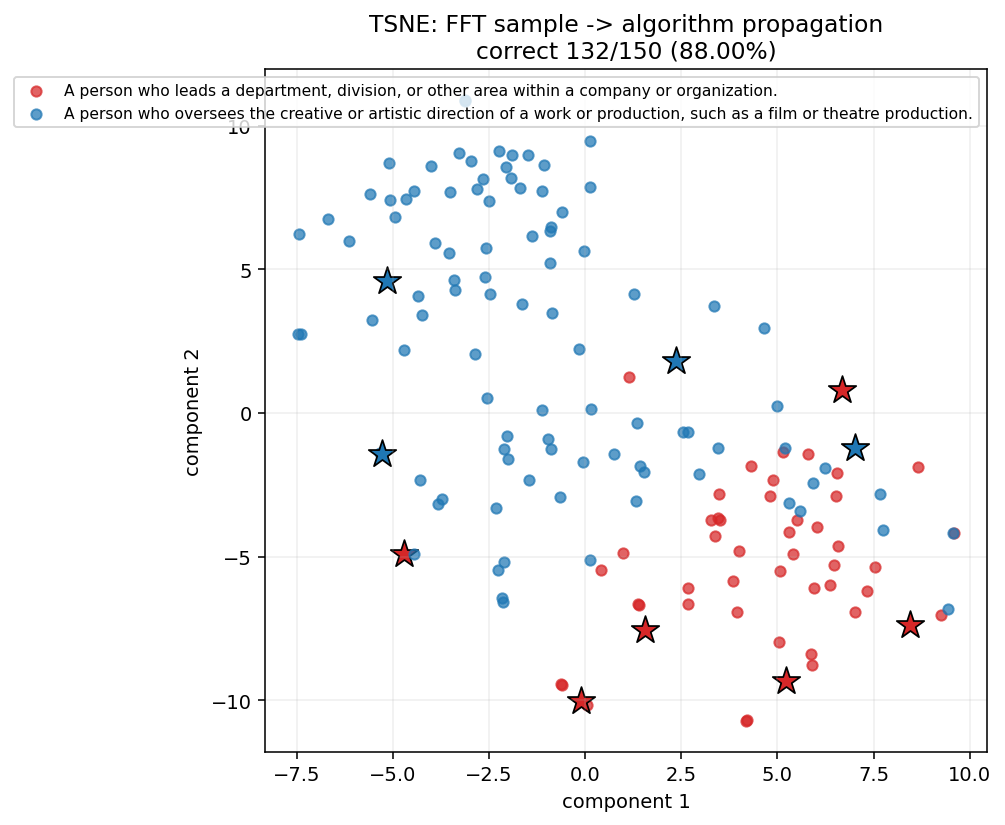

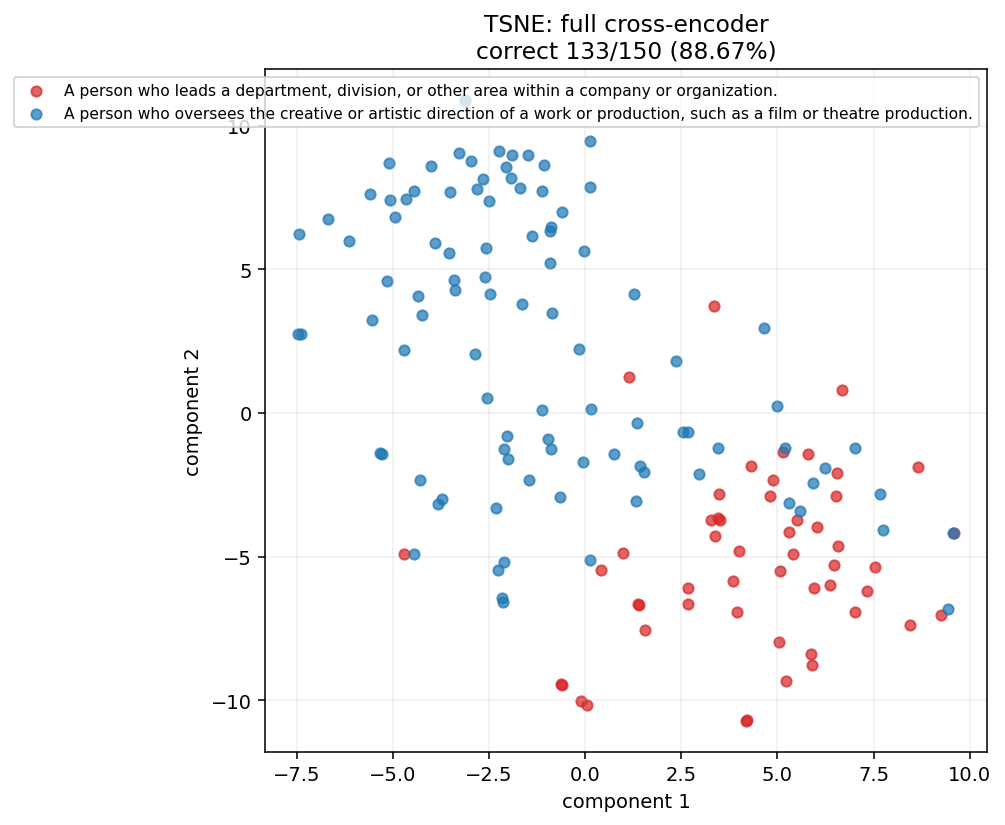

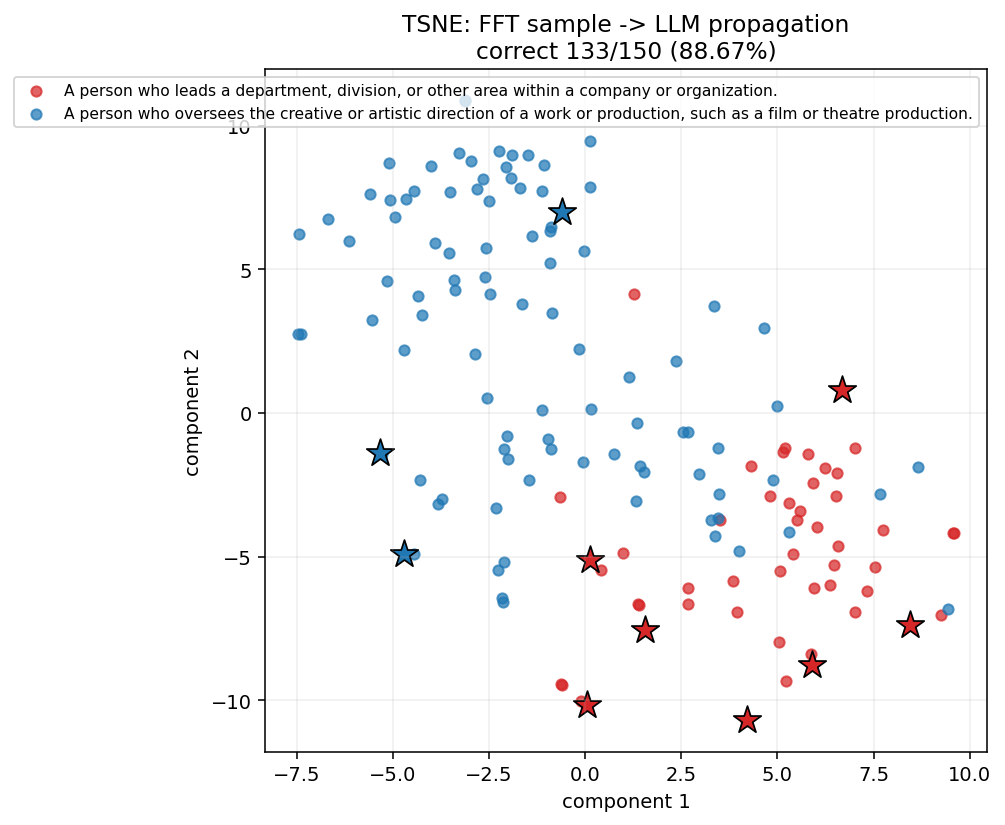

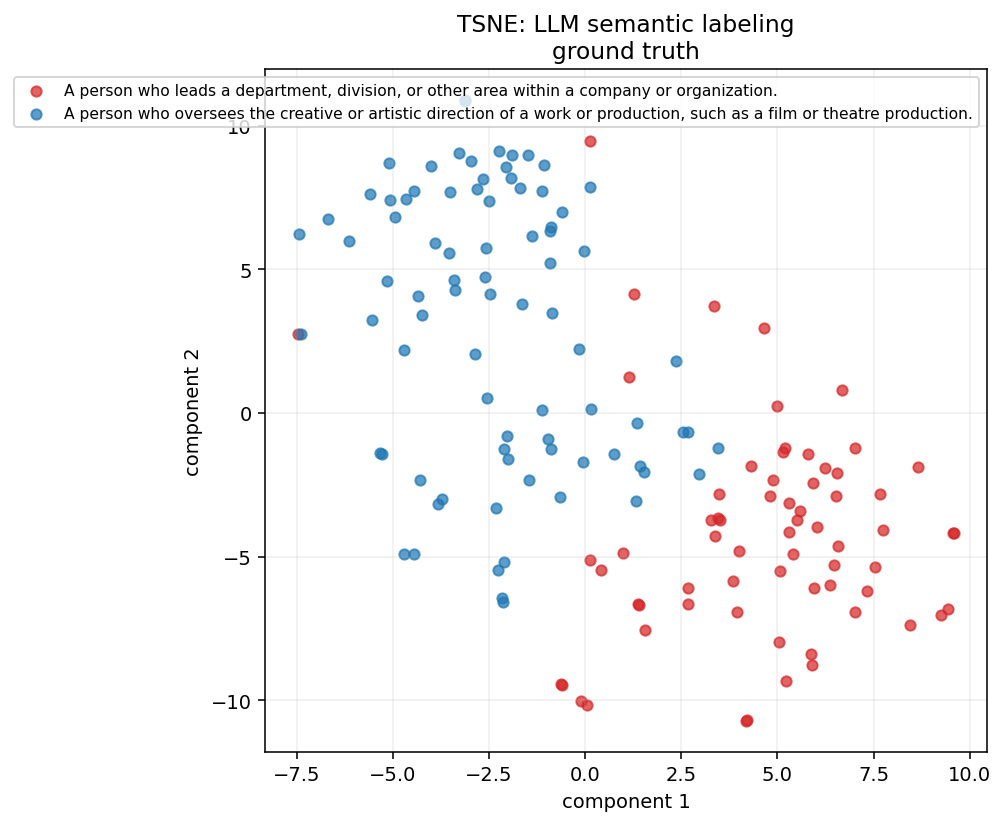

In [17]:
sampled_indices_by_column = {
    "fft_assignment_description": fft_result["sampled_indices"],
}
if fft_llm_result is not None:
    sampled_indices_by_column["fft_llm_assignment_description"] = fft_llm_result["sampled_indices"]

print_fft_provenance_summary(comparison_df)
print_assignment_method_timings(assignment_method_timings)

plot_assignment_comparison(
    records,
    comparison_df,
    sampled_indices_by_column=sampled_indices_by_column,
    method=REDUCTION_METHOD,
    random_state=RANDOM_STATE,
)



In [18]:
# provenance_counts = fft_assignment_df["provenance"].value_counts(dropna=False).rename_axis("provenance").reset_index(name="count")
# display(provenance_counts)
#
# display(
#     fft_assignment_df[[
#         "record_index",
#         "title",
#         "kind",
#         "matched_text",
#         "assigned_description",
#         "provenance",
#         "score",
#     ]].head(50)
# )
#
# display(
#     full_assignment_df[[
#         "record_index",
#         "title",
#         "kind",
#         "matched_text",
#         "assigned_description",
#         "score",
#     ]].head(50)
# )
#
# if llm_assignment_df is not None:
#     display(
#         llm_assignment_df[[
#             "record_index",
#             "title",
#             "kind",
#             "matched_text",
#             "assigned_description",
#             "provenance",
#             "llm_reason",
#             "llm_cache_hit",
#         ]].head(50)
#     )
# else:
#     print("LLM validation is disabled.")
